In [1]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join as pjoin
import os
from scipy.stats import truncnorm
import scipy.stats
from scipy.optimize import minimize
from tqdm import tqdm
import pickle
import torch
import h5py
import corner

In [2]:
def get_post_dir():
    post_dir = '/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm_polybin/models/galaxy'
    post_dir = '/mnt/extraspace/deaglan/ltu/posterior_tests/galaxy'
    post_dir = '/anvil/scratch/x-dbartlett/cmass/quijote/nbody_nonoise_appended/models/galaxy'
    return post_dir


def get_all_summaries():
    """
    Get all available summary statistics.

    Returns:
        :summaries (list): List of summary statistic identifiers
    """
    post_dir = get_post_dir()
    print('Getting summaries from:', post_dir)
    summaries = sorted([d for d in os.listdir(post_dir) if os.path.isdir(pjoin(post_dir, d))])
    return summaries


def get_samples(summary):
    """
    Get posterior samples and true parameters for a given summary statistic.

    Parameters:
        :summary (str): The summary statistic identifier

    Returns:
        :samples_dict (dict): Dictionary of posterior samples arrays, each of shape (num_samples, num_test_points)
        :theta_true_dict (dict): Dictionary of true parameter values arrays, each of shape (num_test_points)
    """
    
    # Load samples
    post_dir = get_post_dir()
    dirname = pjoin(post_dir, summary, 'kmin-0.0_kmax-0.4')
    samples = np.load(pjoin(dirname, 'posterior_samples.npy'))
    theta_true = np.load(pjoin(dirname, 'theta_test.npy'))

    # Check whether we have appended noise parameters
    if samples.shape[-1] == 5:
        has_noise_params = False
    elif samples.shape[-1] == 7:
        has_noise_params = True
    else:
        raise ValueError(f"Unexpected number of parameters in samples: {samples.shape[-1]}")

    # Convert to dictionary format
    param_names = ['Omega_m', 'Omega_b', 'h', 'ns', 'sigma8']
    if has_noise_params:
        param_names += ['sigma_rad', 'sigma_tran']
    samples_dict = {name: samples[..., i] for i, name in enumerate(param_names)}
    theta_true_dict = {name: theta_true[..., i] for i, name in enumerate(param_names)}

    return samples_dict, theta_true_dict


def compute_posterior_std(samples):
    """
    Compute the posterior standard deviation for each parameter.

    Parameters:
        :samples (dict): Dictionary of posterior samples arrays

    Returns:
        :std_dict (dict): Dictionary of posterior standard deviations for each parameter
    """
    std_dict = {name: np.std(samples[name], axis=0) for name in samples}
    return std_dict

Recreate plot like Matt has

Getting summaries from: /anvil/scratch/x-dbartlett/cmass/quijote/nbody_nonoise_appended/models/galaxy
Processing summary: nbar+zPk0
Processing summary: nbar+zPk0+zPk2+zPk4
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0+zBk2
Processing summary: nbar+zPk0+zPk2+zPk4+zQk0


Text(0.5, 1.0, 'Omega_m')

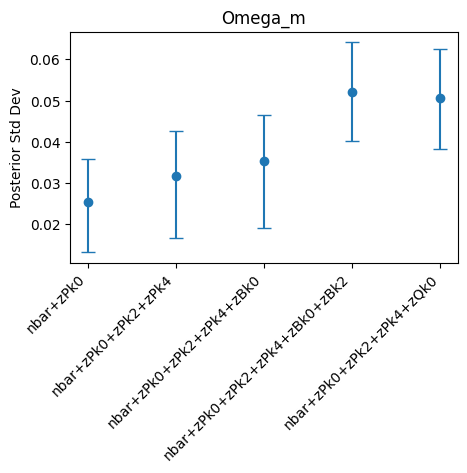

In [3]:
summaries = get_all_summaries()

all_std = []
par = 'Omega_m'

for summary in summaries:
    print(f"Processing summary: {summary}")
    samps, trues = get_samples(summary)
    std_dict = compute_posterior_std(samps)
    all_std.append(std_dict[par])

all_std = np.array(all_std)
all_std_mean = np.mean(all_std, axis=1)
all_std_upper = np.percentile(all_std, 84, axis=1)
all_std_lower = np.percentile(all_std, 16, axis=1)

# Plotting
plt.figure(figsize=(5, 3))
plt.errorbar(summaries, all_std_mean, yerr=[all_std_mean - all_std_lower, all_std_upper - all_std_mean], fmt='o', capsize=5)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'Posterior Std Dev')
plt.title(par)


Check true vs predicted

Getting summaries from: /anvil/scratch/x-dbartlett/cmass/quijote/nbody_nonoise_appended/models/galaxy
Processing summary: nbar+zPk0
Processing summary: nbar+zPk0+zPk2+zPk4
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0+zBk2
Processing summary: nbar+zPk0+zPk2+zPk4+zQk0


/tmp/ipykernel_2897107/1843742587.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


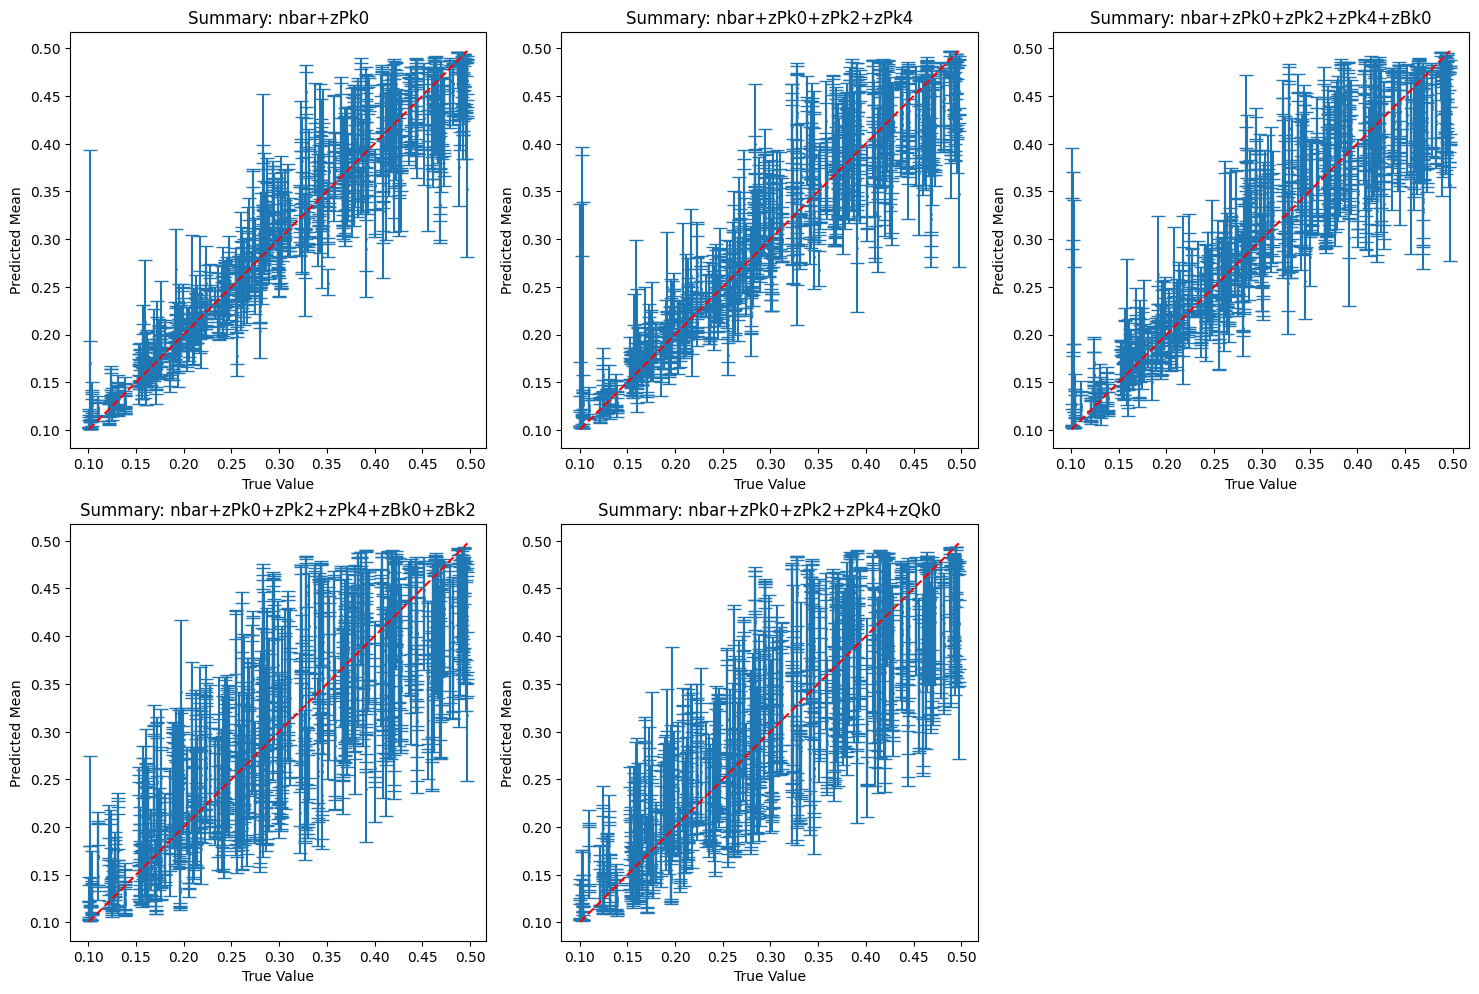

In [4]:
summaries = get_all_summaries()
par = 'Omega_m'

ncol = 3
nrow = (len(summaries) + ncol - 1) // ncol

fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow), constrained_layout=True)
axs = axs.flatten()

for i, summary in enumerate(summaries):
    print(f"Processing summary: {summary}")
    samps, trues = get_samples(summary)
    
    ax = axs[i]
    means = np.median(samps[par], axis=0)
    upper = np.percentile(samps[par], 84, axis=0)
    lower = np.percentile(samps[par], 16, axis=0)
    ax.errorbar(trues[par], means, yerr=[means - lower, upper - means], fmt='o', capsize=5, zorder=0, ms=1)
    ax.plot([trues[par].min(), trues[par].max()], [trues[par].min(), trues[par].max()], 'r--', zorder=1)
    ax.set_xlabel('True Value')
    ax.set_ylabel('Predicted Mean')
    ax.set_title(f'Summary: {summary}')

    ax.set_aspect('equal')

plt.tight_layout()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

Identify cases with large differences between posterior runs

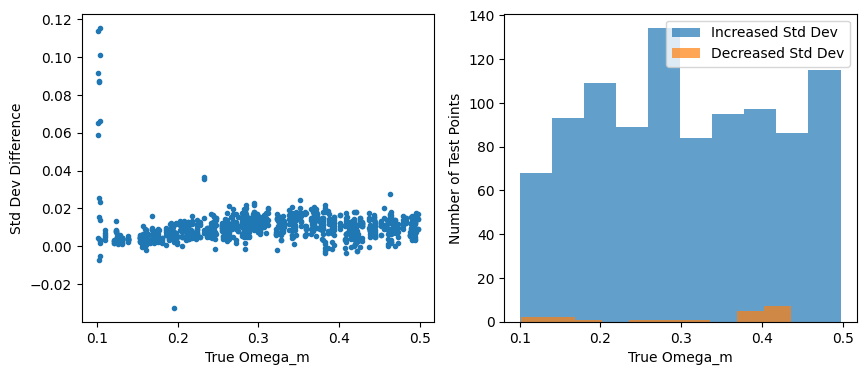

In [5]:
s0 = 'nbar+zPk0'
s1 = 'nbar+zPk0+zPk2+zPk4+zBk0'
par = 'Omega_m'

samps_0, trues_0 = get_samples(s0)
std_dict_0 = compute_posterior_std(samps_0)

samps_1, trues_1 = get_samples(s1)
std_dict_1 = compute_posterior_std(samps_1)

# Find indices for which the change in std is largest
std_diff = std_dict_1[par] - std_dict_0[par]
# largest_diff_indices = np.argsort(np.abs(std_diff))[-5:]
# for idx in largest_diff_indices:
#     print(f"Test point {idx}:")
#     print(f"  True value: {trues_0[par][idx]}")
#     print(f"  Std with {s0}: {std_dict_0[par][idx]}")
#     print(f"  Std with {s1}: {std_dict_1[par][idx]}")
#     print(f"  Difference in Std: {std_diff[idx]}")
#     print()

# Plot comparison
fig, axs = plt.subplots(1, 2, figsize=(10, 4),)
axs[0].plot(trues_0[par], std_diff, '.')
m = std_diff > 0
axs[1].hist(trues_0[par][m], bins=10, alpha=0.7, label='Increased Std Dev')
axs[1].hist(trues_0[par][~m], bins=10, alpha=0.7, label='Decreased Std Dev')
axs[0].set_xlabel(f'True {par}')
axs[0].set_ylabel(f'Std Dev Difference')
axs[1].set_xlabel(f'True {par}')
axs[1].set_ylabel('Number of Test Points')
axs[1].legend()

Plot posteriors at range of Omega_m values

/tmp/ipykernel_2897107/3679899534.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


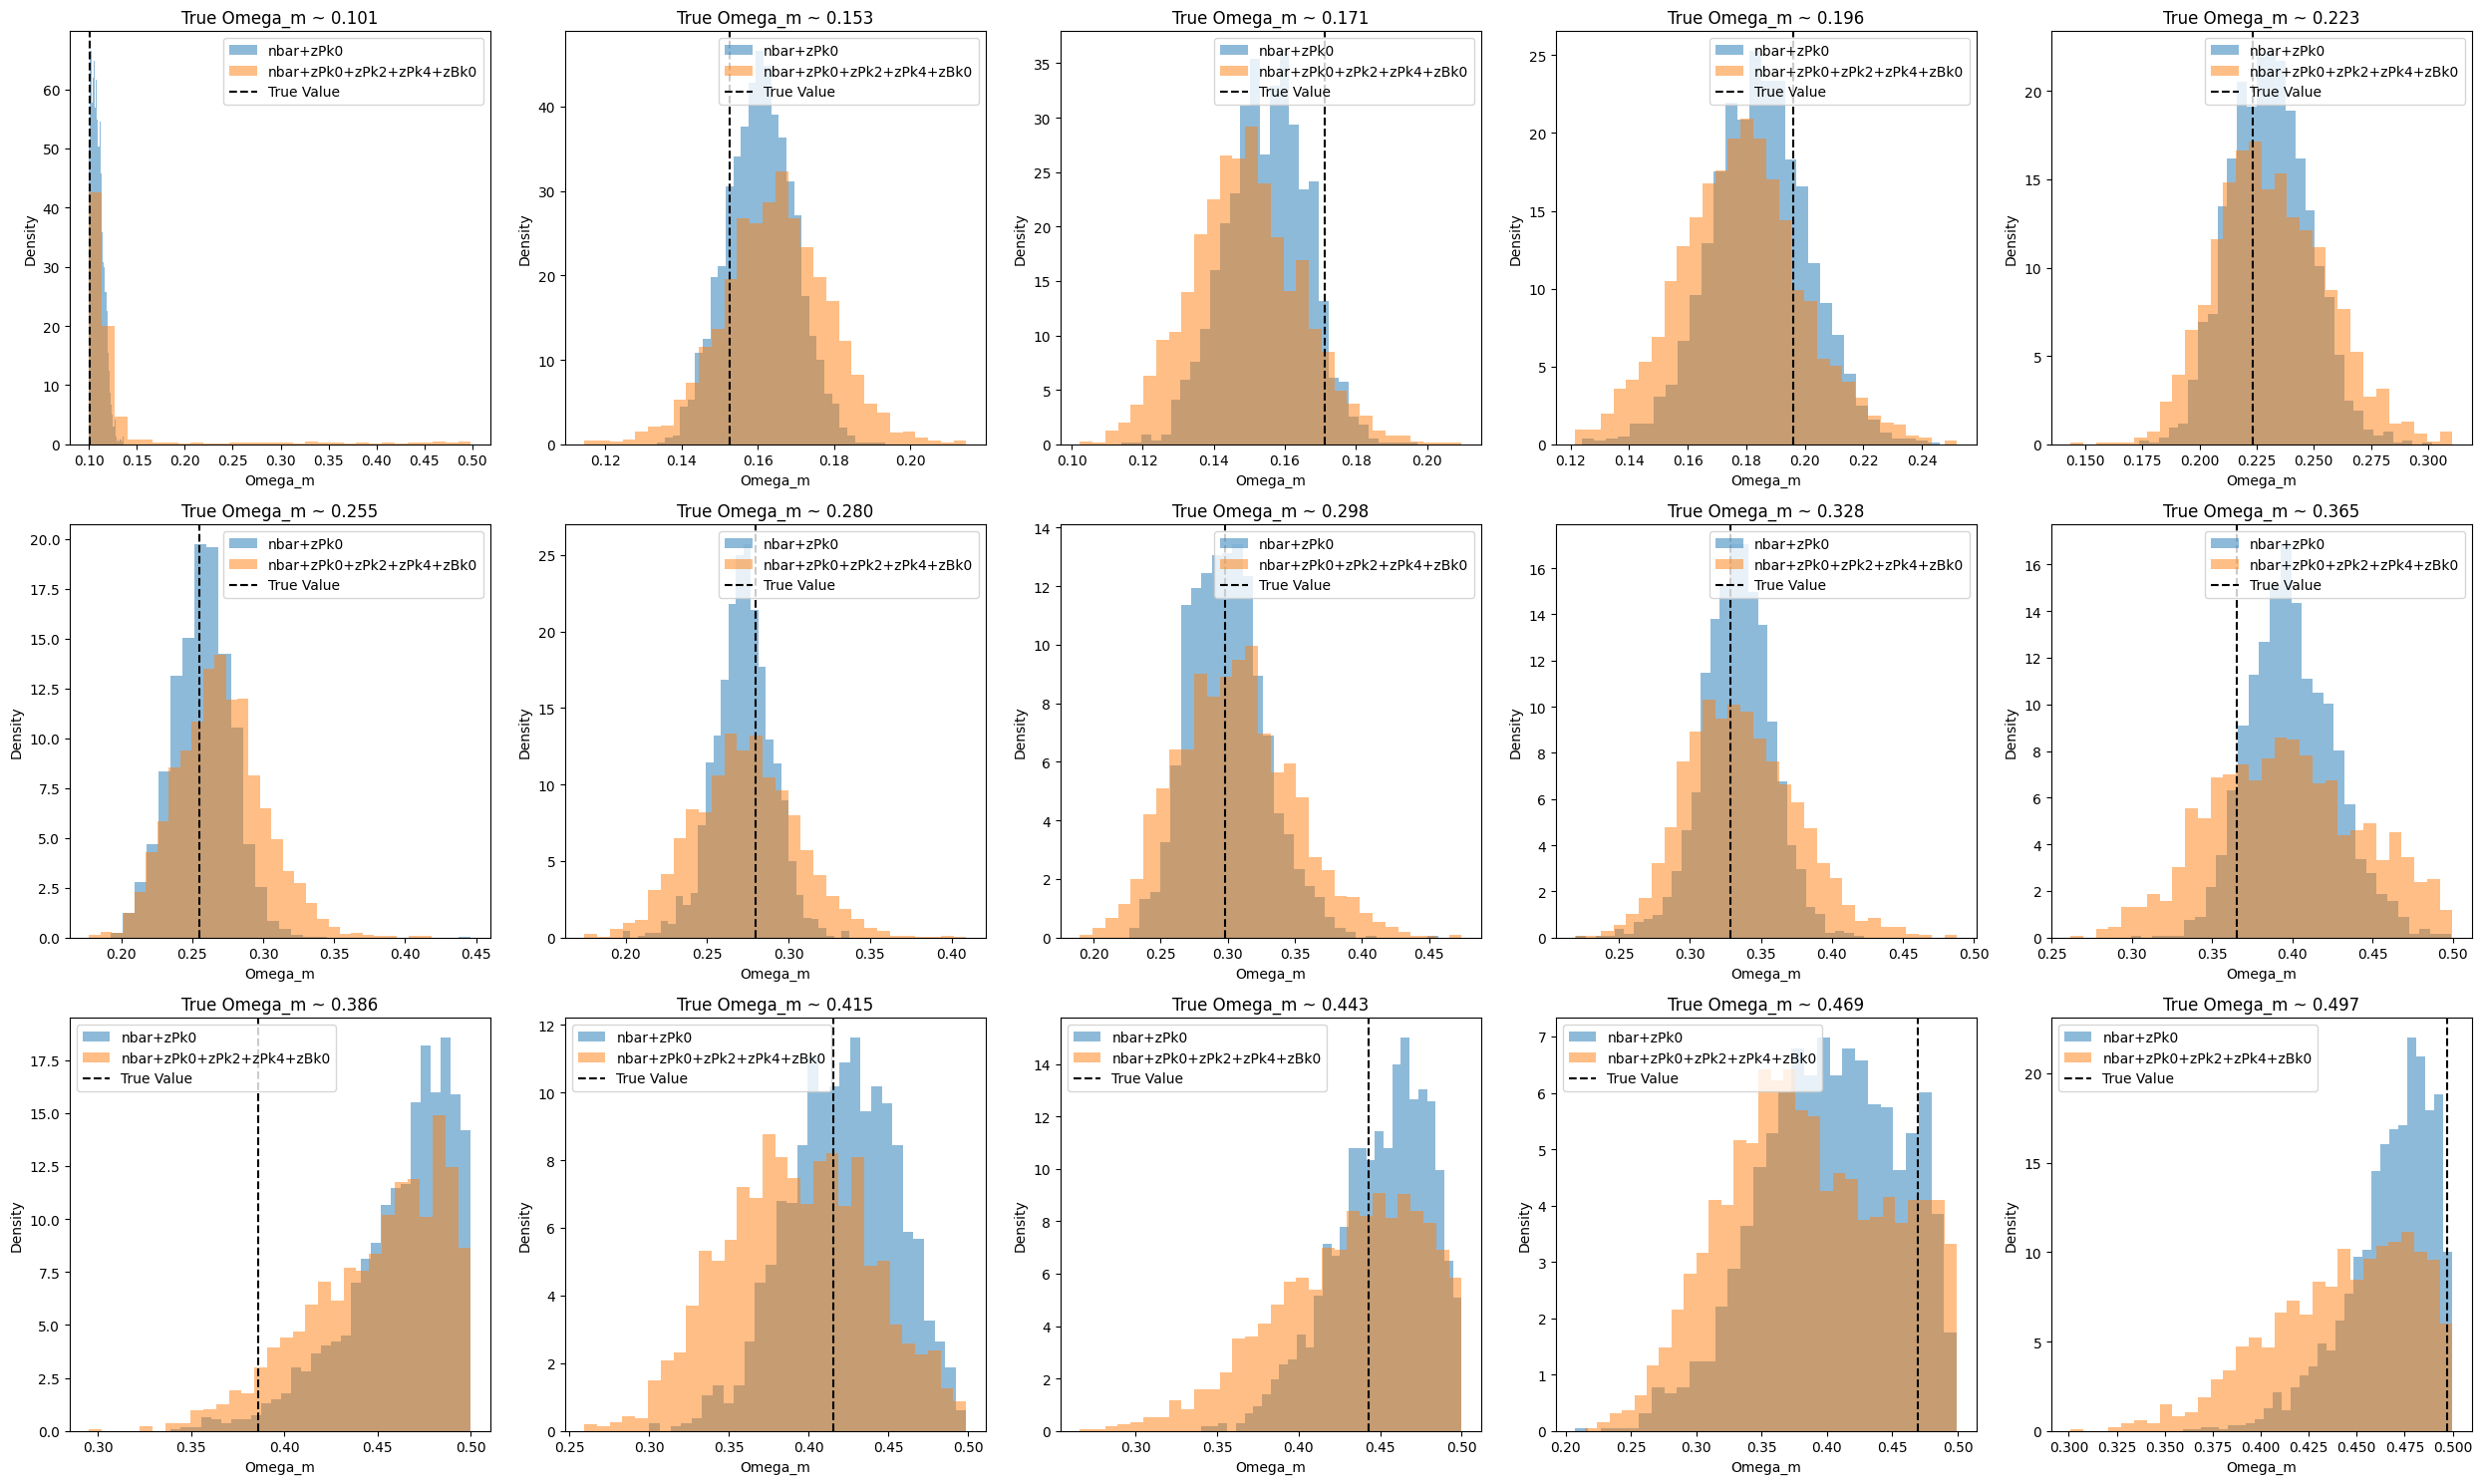

In [6]:
s0 = 'nbar+zPk0'
s1 = 'nbar+zPk0+zPk2+zPk4+zBk0'
par = 'Omega_m'
n_plots = 15

samps_0, trues_0 = get_samples(s0)
std_dict_0 = compute_posterior_std(samps_0)

samps_1, trues_1 = get_samples(s1)
std_dict_1 = compute_posterior_std(samps_1)

unique_vals = np.unique(trues_0[par])
n_plots = min(n_plots, len(unique_vals))
percentiles = np.concatenate(([0], np.linspace(0, 100, n_plots)[1:-1], [100]))

ncol = 5
nrow = nrow = (len(percentiles) + ncol - 1) // ncol

fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow), constrained_layout=True)
axs = axs.flatten()


for i, perc in enumerate(percentiles):
    if perc == 0:
        val = unique_vals.min()
    elif perc == 100:
        val = unique_vals.max()
    else:
        val = np.percentile(unique_vals, perc)
    
    # Find the index of the test point closest to this value
    idx = np.argmin(np.abs(trues_0[par] - val))
    
    ax = axs[i]
    
    # Plot posterior for s0
    ax.hist(samps_0[par][:, idx], bins=30, density=True, alpha=0.5, label=s0)
    
    # Plot posterior for s1
    ax.hist(samps_1[par][:, idx], bins=30, density=True, alpha=0.5, label=s1)
    
    ax.axvline(trues_0[par][idx], color='k', linestyle='--', label='True Value')
    ax.set_title(f'True {par} ~ {trues_0[par][idx]:.3f}')
    ax.set_xlabel(f'{par}')
    ax.set_ylabel('Density')
    ax.legend()
fig.tight_layout()
fig.savefig('compare_posteriors.png', bbox_inches='tight')

# Fit posteriors to truncated Gaussians

In [7]:
def fit_truncated_normal(data, lower, upper):
    """
    Fit a truncated normal distribution to the given data.

    Parameters:
        :data (array-like): The data to fit
        :lower (float): The lower bound of the truncation
        :upper (float): The upper bound of the truncation
    """

    data = np.asarray(data)

    # Check data within bounds
    if np.any(data < lower) or np.any(data > upper):
        raise ValueError("Data contains values outside the specified bounds.")

    # Convert bounds to truncnorm's parameterization
    # a and b are in standard normal units
    def neg_log_likelihood(params):
        mu, sigma = params
        if sigma <= 0:
            return np.inf
        
        a, b = (lower - mu) / sigma, (upper - mu) / sigma
        ll = np.sum(truncnorm.logpdf(data, a, b, loc=mu, scale=sigma))
        return -ll

    # Initial guesses
    mu0 = np.mean(data)
    sigma0 = np.std(data)

    result = minimize(
        neg_log_likelihood,
        x0=[mu0, sigma0],
        method='L-BFGS-B',
        bounds=[(None, None), (1e-6, None)]
    )
    
    mu_hat, sigma_hat = result.x
    return mu_hat, sigma_hat


all_bounds = {
    'Omega_m': (0.1, 0.5),
    'Omega_b': (0.03, 0.07),
    'h': (0.5, 0.9),
    'ns': (0.8, 1.2),
    'sigma8': (0.6, 1.0),
}

100%|██████████| 15/15 [00:00<00:00, 32.85it/s]
/tmp/ipykernel_2897107/518156677.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


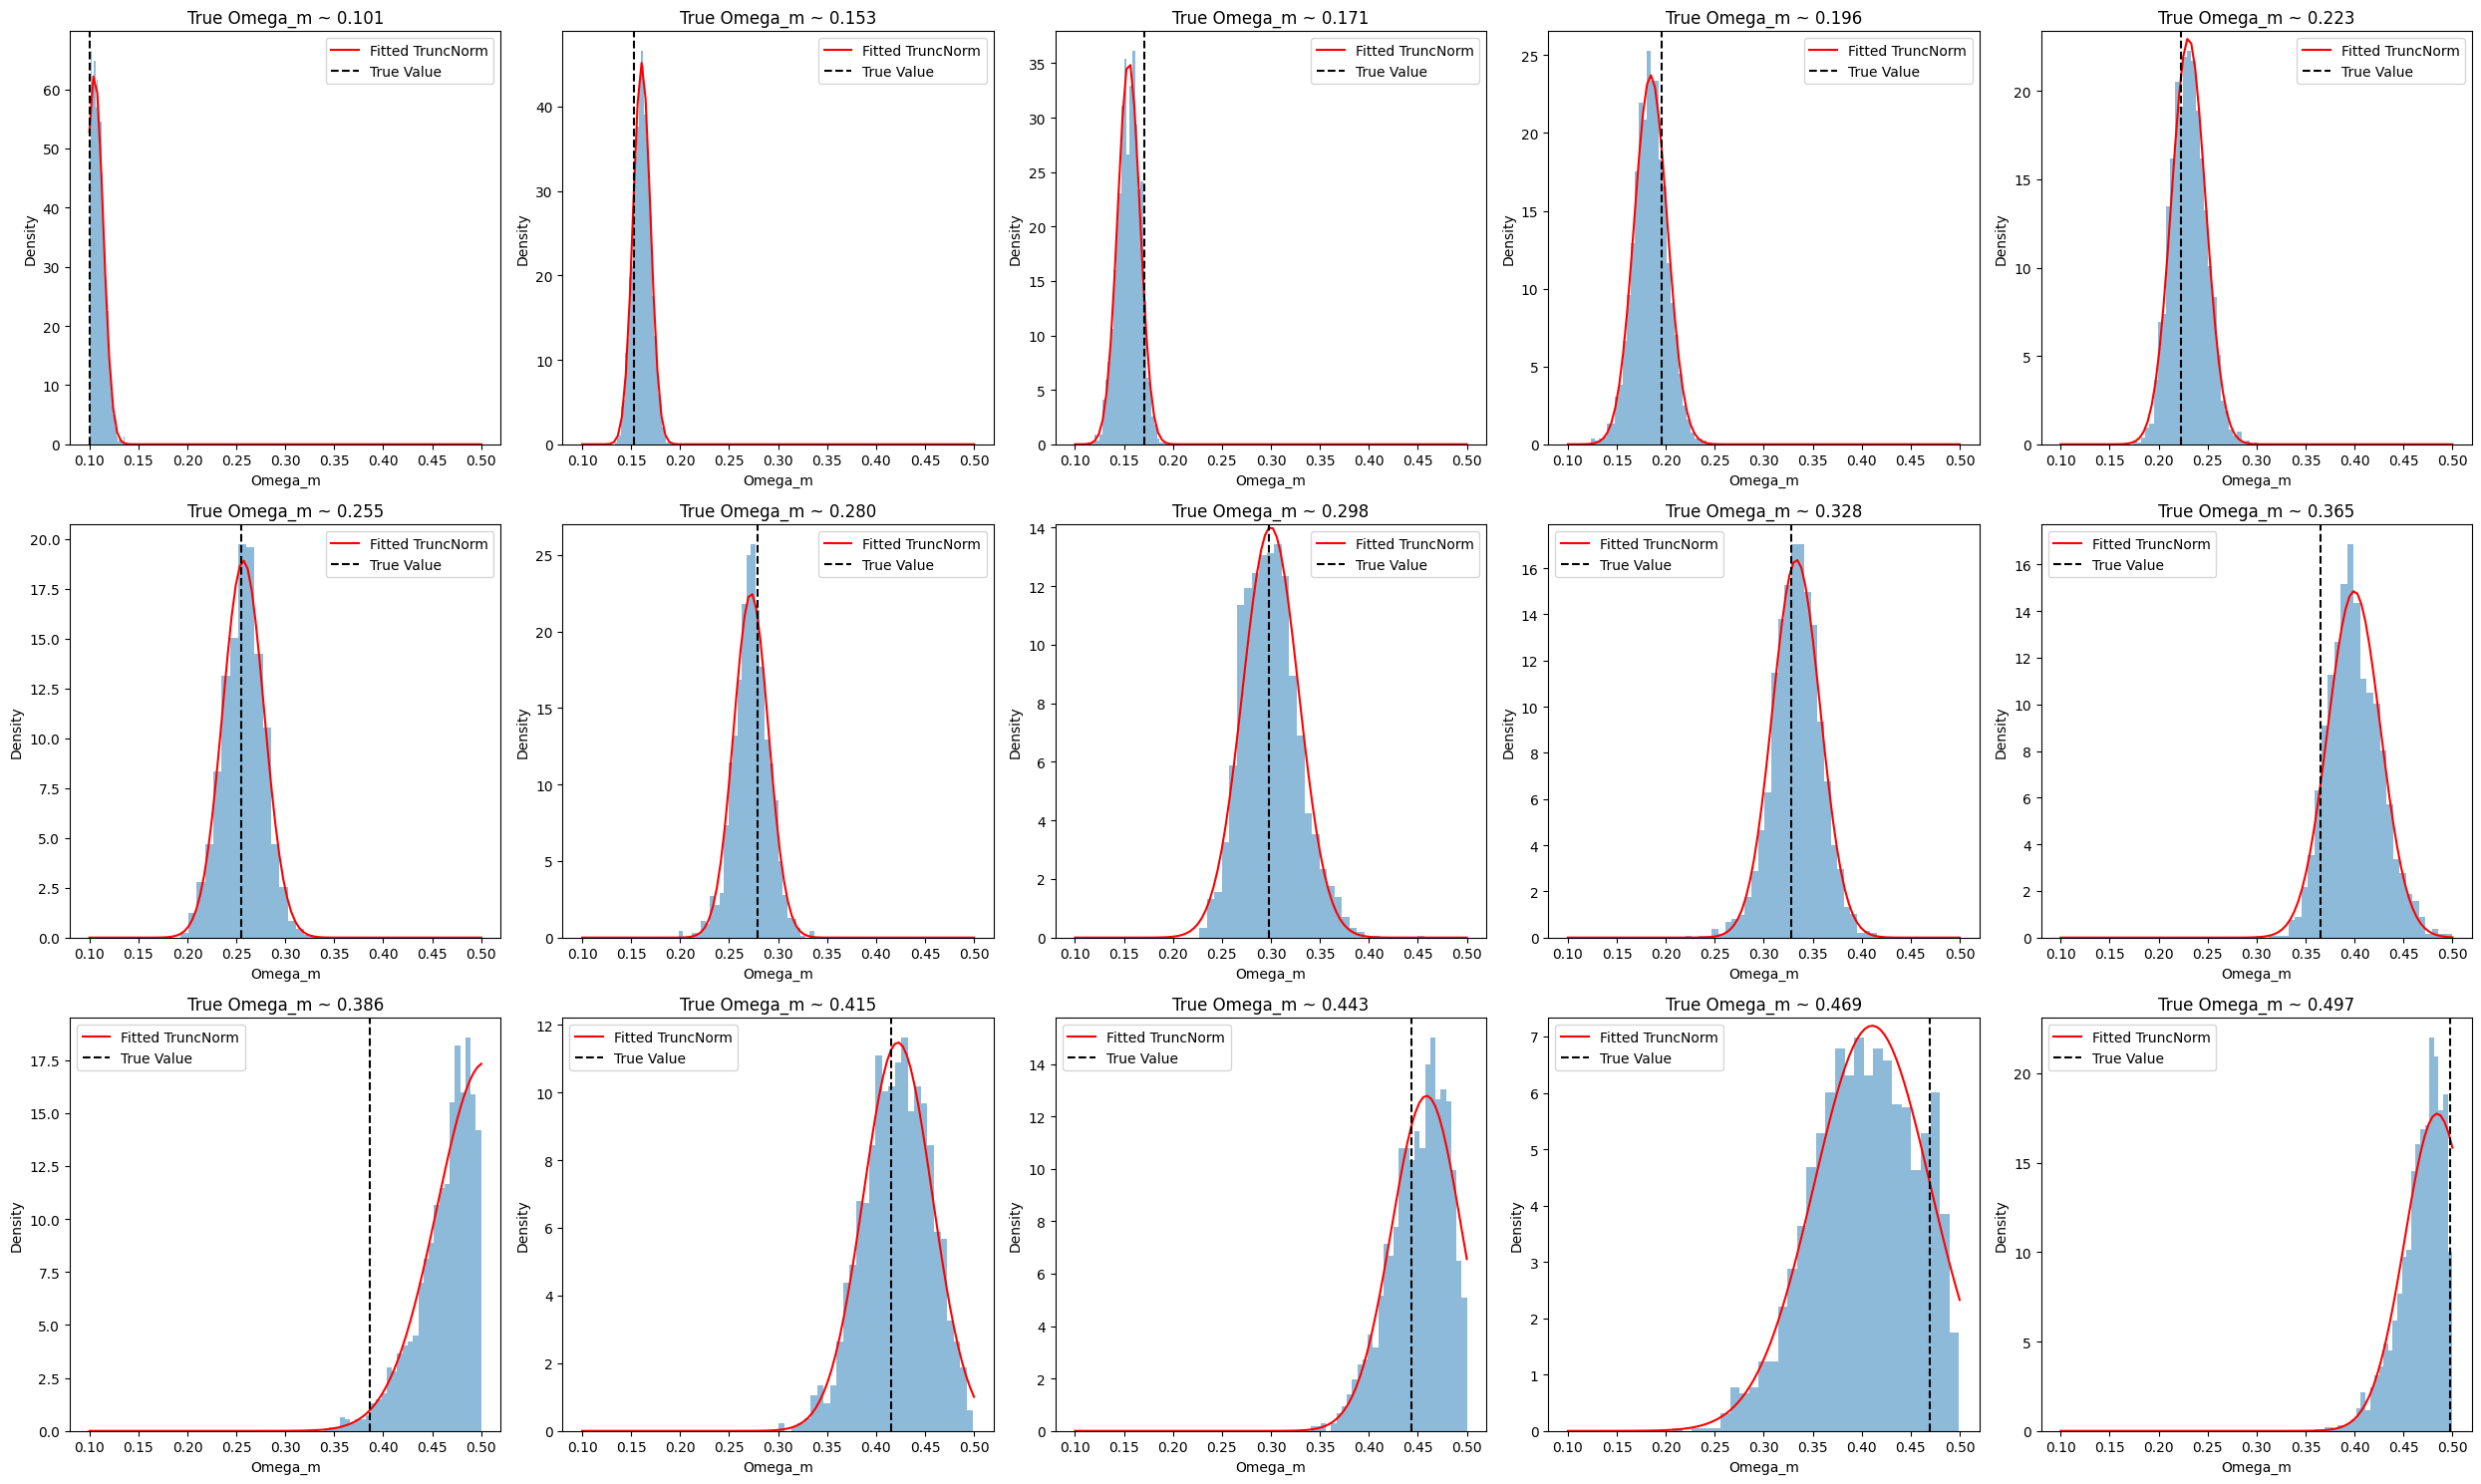

In [8]:
par = 'Omega_m'
n_plots = 15

samps_0, trues_0 = get_samples('nbar+zPk0')

unique_vals = np.unique(trues_0[par])
n_plots = min(n_plots, len(unique_vals))
percentiles = np.concatenate(([0], np.linspace(0, 100, n_plots)[1:-1], [100]))

fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow), constrained_layout=True)
axs = axs.flatten()

for i in tqdm(range(len(percentiles))):
    
    perc = percentiles[i]
    if perc == 0:
        val = unique_vals.min()
    elif perc == 100:
        val = unique_vals.max()
    else:
        val = np.percentile(unique_vals, perc)
    
    # Find the index of the test point closest to this value
    idx = np.argmin(np.abs(trues_0[par] - val))
    
    ax = axs[i]

    # Fit truncated normal to samps_0
    mu, sigma = fit_truncated_normal(samps_0[par][:, idx], *all_bounds[par])
    x = np.linspace(all_bounds[par][0], all_bounds[par][1], 100)
    a, b = (all_bounds[par][0] - mu) / sigma, (all_bounds[par][1] - mu) / sigma
    pdf = truncnorm.pdf(x, a, b, loc=mu, scale=sigma)
    
    # Plot posterior for samps_0
    ax.hist(samps_0[par][:, idx], bins=30, density=True, alpha=0.5)
    # ax.set_yscale('log')
    ylim = ax.get_ylim()
    
    # Plot predicted truncated normal
    ax.plot(x, pdf, 'r-', label='Fitted TruncNorm')
    ax.set_ylim(ylim)
    
    ax.axvline(trues_0[par][idx], color='k', linestyle='--', label='True Value')
    ax.set_title(f'True {par} ~ {trues_0[par][idx]:.3f}')
    ax.set_xlabel(f'{par}')
    ax.set_ylabel('Density')
    ax.legend()
fig.tight_layout()
fig.savefig('posterior_fit_truncnorm.png', bbox_inches='tight')


In [9]:
summaries = get_all_summaries()
par = 'Omega_m'

fitted_mus = {}
fitted_sigmas = {}

for summary in summaries:
    print(f"Processing summary: {summary}")
    samps, trues = get_samples(summary)
    
    mus = []
    sigmas = []
    
    for i in tqdm(range(samps[par].shape[1])):
        mu, sigma = fit_truncated_normal(samps[par][:, i], *all_bounds[par])
        mus.append(mu)
        sigmas.append(sigma)
    
    fitted_mus[summary] = np.array(mus)
    fitted_sigmas[summary] = np.array(sigmas)

Getting summaries from: /anvil/scratch/x-dbartlett/cmass/quijote/nbody_nonoise_appended/models/galaxy
Processing summary: nbar+zPk0


100%|██████████| 990/990 [00:11<00:00, 88.17it/s] 


Processing summary: nbar+zPk0+zPk2+zPk4


100%|██████████| 990/990 [00:10<00:00, 90.14it/s] 


Processing summary: nbar+zPk0+zPk2+zPk4+zBk0


...

Processing summary: nbar+zPk0+zPk2+zPk4+zBk0+zBk2


100%|██████████| 990/990 [00:11<00:00, 83.43it/s] 


Processing summary: nbar+zPk0+zPk2+zPk4+zQk0


100%|██████████| 990/990 [00:11<00:00, 83.74it/s] 


100%|██████████| 990/990 [00:12<00:00, 76.62it/s]


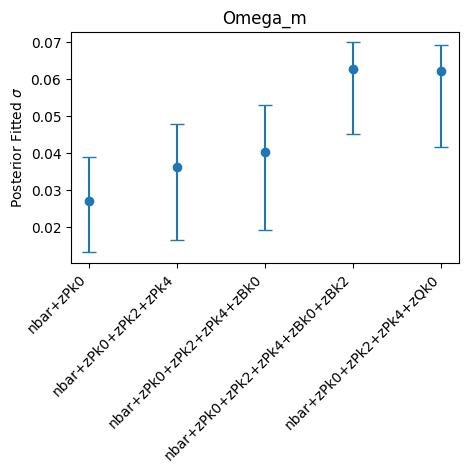

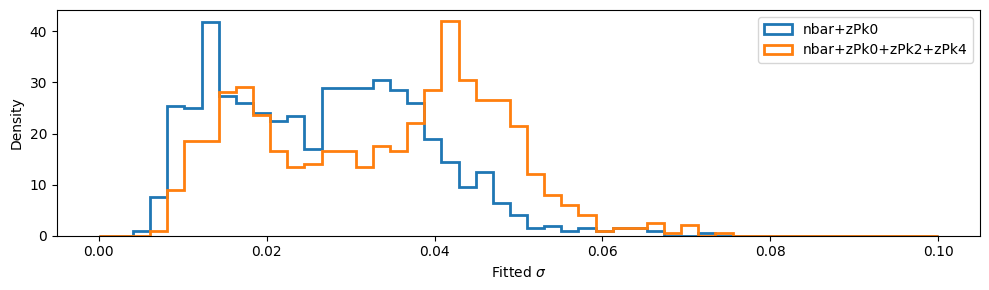

In [10]:
all_std_mean = np.array([np.median(fitted_sigmas[summary]) for summary in summaries])
all_std_upper = np.array([np.percentile(fitted_sigmas[summary], 84) for summary in summaries])
all_std_lower = np.array([np.percentile(fitted_sigmas[summary], 16) for summary in summaries])

# Plotting
plt.figure(figsize=(5, 3))
plt.errorbar(summaries, all_std_mean, yerr=[all_std_mean - all_std_lower, all_std_upper - all_std_mean], fmt='o', capsize=5)
plt.xticks(rotation=45, ha='right')
plt.ylabel(r'Posterior Fitted $\sigma$')
plt.title(par)
plt.savefig('fitted_sigma_summary.png', bbox_inches='tight')

plt.figure(figsize=(10, 3))
bins = np.linspace(0, (all_bounds[par][1] - all_bounds[par][0]) / 4, 50)
plot_kwargs = {'bins': bins, 'density': True, 'histtype': 'step', 'lw': 2}
for summary in summaries[:2]:
    plt.hist(fitted_sigmas[summary], label=summary, **plot_kwargs)
plt.xlabel(r'Fitted $\sigma$')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fitted_sigma_distributions.png', bbox_inches='tight')


# Compare posterior information

To compare the information between two posteriors, we consider two summaries of the posterior.

## KL Divergence

The Kullback-Leibler (KL) divergence $D_{KL}(Q || P)$ measures how much information is lost when approximating distribution $Q$ with distribution $P$:

$$D_{KL}(Q || P) = \int Q(\theta|x) \log\frac{Q(\theta|x)}{P(\theta|x)} d\theta$$

We approximate this using samples $\theta_i \sim Q(\theta|x)$:

$$D_{KL}(Q || P) \approx \frac{1}{N} \sum_{i=1}^{N} \left[\log Q(\theta_i|x) - \log P(\theta_i|x)\right]$$

**Interpretation**: A large positive $D_{KL}(Q || P)$ indicates that $Q$ contains more information than $P$ (i.e., $Q$ is more informative or has lower uncertainty).

## Change in Entropy

The differential entropy of a posterior distribution $P$ is:

$$H(P) = -\int P(\theta|x) \log P(\theta|x) d\theta$$

We compare two posteriors by computing the change in entropy:

$$\Delta H = H(Q) - H(P)$$

Approximating using samples:

$$H(P) \approx -\frac{1}{N} \sum_{i=1}^{N} \log P(\theta_i|x) \quad \text{for } \theta_i \sim P(\theta|x)$$

$$H(Q) \approx -\frac{1}{N} \sum_{i=1}^{N} \log Q(\theta_i|x) \quad \text{for } \theta_i \sim Q(\theta|x)$$

**Interpretation**: 
- If $\Delta H < 0$, then $Q$ has lower entropy than $P$, meaning $Q$ is more informative (more concentrated, less uncertain)
- If $\Delta H > 0$, then $P$ is more informative than $Q$

Both metrics provide complementary views of how much additional information one posterior provides over another.

In [20]:
def load_posterior(summary):
    print(f"Loading posterior for summary: {summary}")
    post_dir = get_post_dir()
    dirname = pjoin(post_dir, summary, 'kmin-0.0_kmax-0.4')
    return pickle.load(open(pjoin(dirname, 'posterior.pkl'), 'rb'))

def compute_KL_divergence(samples_p, posterior_p, posterior_q, x_p, x_q):
    """
    Compute the KL divergence D_KL(P || Q) between two posterior distributions P and Q.

    D_kl(P || Q) = ∫ P(θ|x) log(P(θ|x) / Q(θ|x)) dθ
    \approx \frac{1}{N} \sum_{i=1}^{N} [ log(P(θ_i|x)) - log(Q(θ_i|x)) ] for θ_i ~ P(θ|x)

    If KL divergence is large, P is more informative than Q.

    Parameters:
        :samples_p (np.ndarray): Samples from posterior distribution P
        :posterior_p (callable): Posterior distribution P with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :posterior_q (callable): Posterior distribution Q with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :x_p (np.ndarray): Observed data for posterior P
        :x_q (np.ndarray): Observed data for posterior Q

    Returns:
        :D_KL (float): The KL divergence D_KL(P || Q)
    """

    samples_torch = torch.tensor(samples_p, dtype=torch.float32)
    x_p_torch = torch.tensor(x_p, dtype=torch.float32)
    x_q_torch = torch.tensor(x_q, dtype=torch.float32)

    log_p = posterior_p.log_prob(samples_torch, x_p_torch).numpy()
    log_q = posterior_q.log_prob(samples_torch, x_q_torch).numpy()
    
    D_KL = np.mean(log_p - log_q)
    
    return D_KL


def compute_delta_entropy(samples_p, samples_q, posterior_p, posterior_q, x_p, x_q):
    """
    Compute the change in entropy ΔH = H(Q) - H(P) between two posterior distributions P and Q.

    ΔH = -∫ Q(θ|x) log Q(θ|x) dθ + ∫ P(θ|x) log P(θ|x) dθ

    If ΔH < 0, Q is more informative than P.

    Parameters:
        :samples_p (np.ndarray): Samples from posterior distribution P
        :samples_q (np.ndarray): Samples from posterior distribution Q
        :posterior_p (callable): Posterior distribution P with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :posterior_q (callable): Posterior distribution Q with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :x_p (np.ndarray): Observed data for posterior P
        :x_q (np.ndarray): Observed data for posterior Q

    Returns:
        :delta_H (float): The change in entropy ΔH = H(Q) - H(P)
    """

    samples_p_torch = torch.tensor(samples_p, dtype=torch.float32)
    samples_q_torch = torch.tensor(samples_q, dtype=torch.float32)
    x_p_torch = torch.tensor(x_p, dtype=torch.float32)
    x_q_torch = torch.tensor(x_q, dtype=torch.float32)

    log_p = posterior_p.log_prob(samples_p_torch, x_p_torch).numpy()
    log_q = posterior_q.log_prob(samples_q_torch, x_q_torch).numpy()
    
    H_P = -np.mean(log_p)
    H_Q = -np.mean(log_q)
    
    delta_H = H_Q - H_P
    
    return delta_H


def compute_KL_and_delta_H(samples_p, samples_q, posterior_p, posterior_q, x_p, x_q):
    """
    Compute both the KL divergence D_KL(Q || P) and the change in entropy ΔH = H(Q) - H(P) between two posterior distributions P and Q.
    We do this in one function to avoid redundant computations.

    Parameters:
        :samples_p (np.ndarray): Samples from posterior distribution P
        :samples_q (np.ndarray): Samples from posterior distribution Q
        :posterior_p (callable): Posterior distribution P with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :posterior_q (callable): Posterior distribution Q with method log_prob(self, theta: torch.Tensor, x: torch.Tensor)
        :x_p (np.ndarray): Observed data for posterior P
        :x_q (np.ndarray): Observed data for posterior Q

    Returns:
        :D_KL (float): The KL divergence D_KL(P || Q)
        :delta_H (float): The change in entropy ΔH = H(Q) - H(P)

    """
    
    samples_p_torch = torch.tensor(samples_p, dtype=torch.float32)
    samples_q_torch = torch.tensor(samples_q, dtype=torch.float32)
    x_p_torch = torch.tensor(x_p, dtype=torch.float32)
    x_q_torch = torch.tensor(x_q, dtype=torch.float32)

    log_qsamp_ppost = posterior_p.log_prob(samples_q_torch, x_p_torch).numpy()
    log_qsamp_qpost = posterior_q.log_prob(samples_q_torch, x_q_torch).numpy()
    log_psamp_ppost = posterior_p.log_prob(samples_p_torch, x_p_torch).numpy()

    D_KL = np.mean(log_qsamp_qpost) - np.mean(log_qsamp_ppost)

    H_P = -np.mean(log_psamp_ppost)
    H_Q = -np.mean(log_qsamp_qpost)
    delta_H = H_Q - H_P

    return D_KL, delta_H


Double-check KL divergence code


Exact D_KL(s1 || s0): 2.1039
Computed D_KL(s1 || s0): 2.1328
Computed ΔH (H(s1) - H(s0)): -3.4904 (should be negative as s1 is more informative than s0)
From other function: D_KL: 2.1328, ΔH: -3.4904

Exact D_KL(s0 || s1): 10.0461
Computed D_KL(s0 || s1): 10.0860
Computed ΔH (H(s0) - H(s1)): 3.4904 (should be positive as s0 is less informative than s1)
From other function: D_KL: 10.0860, ΔH: 3.4904


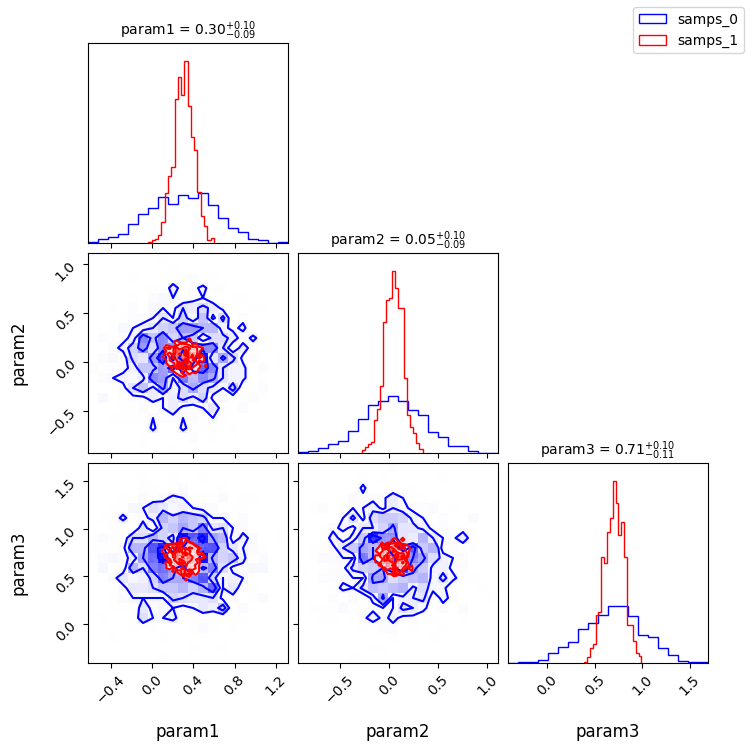

In [21]:
# Make the posteior s0 and s1 be multivariate gaussians
# s1 will have a smaller covariance matrix than s0
# so that D_KL(s1 || s0) should be large

Sigma_0 = np.diag([0.1, 0.1, 0.1])
Sigma_1 = np.diag([0.01, 0.01, 0.01])
mu_0 = np.array([0.3, 0.05, 0.7])
mu_1 = mu_0

samps_0 = np.random.multivariate_normal(mu_0, Sigma_0, size=1000)
samps_1 = np.random.multivariate_normal(mu_1, Sigma_1, size=1000)

# Plot both sets of samples with corner
figure = corner.corner(samps_0, labels=['param1', 'param2', 'param3'], color='blue', label_kwargs={'fontsize': 12}, show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 10}, hist_kwargs={'density': True}, plot_datapoints=False)
corner.corner(samps_1, fig=figure, labels=['param1', 'param2', 'param3'], color='red', label_kwargs={'fontsize': 12}, show_titles=True, title_fmt='.2f', title_kwargs={"fontsize": 10}, hist_kwargs={'density': True}, plot_datapoints=False) 
figure.legend(['samps_0', 'samps_1'])

class GaussianPosterior:
    def __init__(self, mu, Sigma):
        self.mu = torch.tensor(mu, dtype=torch.float32)
        self.Sigma = torch.tensor(Sigma, dtype=torch.float32)
        self.Sigma_inv = torch.inverse(self.Sigma)
        self.dim = self.mu.shape[0]
        self.norm_const = -0.5 * self.dim * np.log(2 * np.pi) - 0.5 * torch.logdet(self.Sigma)
        # self.norm_const = 0

    def log_prob(self, theta: torch.Tensor, x: torch.Tensor):
        theta = torch.atleast_2d(theta)
        diff = theta - self.mu
        exponent = -0.5 * torch.einsum('bi,ij,bj->b', diff, self.Sigma_inv, diff)
        return self.norm_const + exponent
    
posterior_0 = GaussianPosterior(mu_0, Sigma_0)
posterior_1 = GaussianPosterior(mu_1, Sigma_1)

x_0 = np.ones(123)
x_1 = np.ones(123)

Sigma0_inv = np.linalg.inv(Sigma_0)
k = mu_0.shape[0]
D_KL_1_0_exact = 0.5 * (np.trace(Sigma0_inv @ Sigma_1) - k + (mu_0 - mu_1).T @ Sigma0_inv @ (mu_0 - mu_1)  + np.log(np.linalg.det(Sigma_0) / np.linalg.det(Sigma_1)))
print(f"\nExact D_KL(s1 || s0): {D_KL_1_0_exact:.4f}")
D_KL_1_0 = compute_KL_divergence(samps_1, posterior_1, posterior_0, x_1, x_0)
print(f"Computed D_KL(s1 || s0): {D_KL_1_0:.4f}")
Delta_H = compute_delta_entropy(samps_0, samps_1, posterior_0, posterior_1, x_0, x_1)
print(f"Computed ΔH (H(s1) - H(s0)): {Delta_H:.4f} (should be negative as s1 is more informative than s0)")
res = compute_KL_and_delta_H(samps_0, samps_1, posterior_0, posterior_1, x_0, x_1)
print(f"From other function: D_KL: {res[0]:.4f}, ΔH: {res[1]:.4f}")

Sigma1_inv = np.linalg.inv(Sigma_1)
k = mu_0.shape[0]
D_KL_0_1_exact = 0.5 * (np.trace(Sigma1_inv @ Sigma_0) - k + (mu_1 - mu_0).T @ Sigma1_inv @ (mu_1 - mu_0)  + np.log(np.linalg.det(Sigma_1) / np.linalg.det(Sigma_0)))
print(f"\nExact D_KL(s0 || s1): {D_KL_0_1_exact:.4f}")
D_KL_0_1 = compute_KL_divergence(samps_0, posterior_0, posterior_1, x_0, x_1)
print(f"Computed D_KL(s0 || s1): {D_KL_0_1:.4f}")
Delta_H = compute_delta_entropy(samps_1, samps_0, posterior_1, posterior_0, x_1, x_0)
print(f"Computed ΔH (H(s0) - H(s1)): {Delta_H:.4f} (should be positive as s0 is less informative than s1)")
res = compute_KL_and_delta_H(samps_1, samps_0, posterior_1, posterior_0, x_1, x_0)
print(f"From other function: D_KL: {res[0]:.4f}, ΔH: {res[1]:.4f}")

Run on real summaries

In [22]:
s0 = 'nbar+zPk0'
s1 = 'nbar+zPk0+zPk2+zPk4+zBk0'

# Load posteriors
post_0 = load_posterior(s0)
post_1 = load_posterior(s1)

# Load samples
post_dir = get_post_dir()
dirname_0 = pjoin(post_dir, s0, 'kmin-0.0_kmax-0.4')
samps_0 = np.load(pjoin(dirname_0, 'posterior_samples.npy'))
dirname_1 = pjoin(post_dir, s1, 'kmin-0.0_kmax-0.4')
samps_1 = np.load(pjoin(dirname_1, 'posterior_samples.npy'))

# Load true data
x0 = np.load(pjoin(dirname_0, 'x_test.npy'))
x1 = np.load(pjoin(dirname_1, 'x_test.npy'))

ntest = 400
ntest = min(ntest, samps_1.shape[1])
indices = np.random.choice(samps_1.shape[1], size=ntest, replace=False)
all_D_KL = np.zeros(indices.shape[0])
all_delta_H = np.zeros(indices.shape[0])

for i, idx in enumerate(tqdm(indices)):
    D_KL, delta_H = compute_KL_and_delta_H(
        samples_p=samps_0[:, idx, :],
        samples_q=samps_1[:, idx, :],
        posterior_p=post_0,
        posterior_q=post_1,
        x_p=x0[idx, :],
        x_q=x1[idx, :],
    )
    all_D_KL[i] = D_KL
    all_delta_H[i] = delta_H

Loading posterior for summary: nbar+zPk0


/home/x-dbartlett/.conda/envs/2024.02-py311/cmass/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading posterior for summary: nbar+zPk0+zPk2+zPk4+zBk0


 47%|████▋     | 188/400 [01:48<02:01,  1.74it/s]


KeyboardInterrupt: 

Number of test points more informative with nbar+zPk0+zPk2+zPk4+zBk0 than nbar+zPk0: 247 out of 400


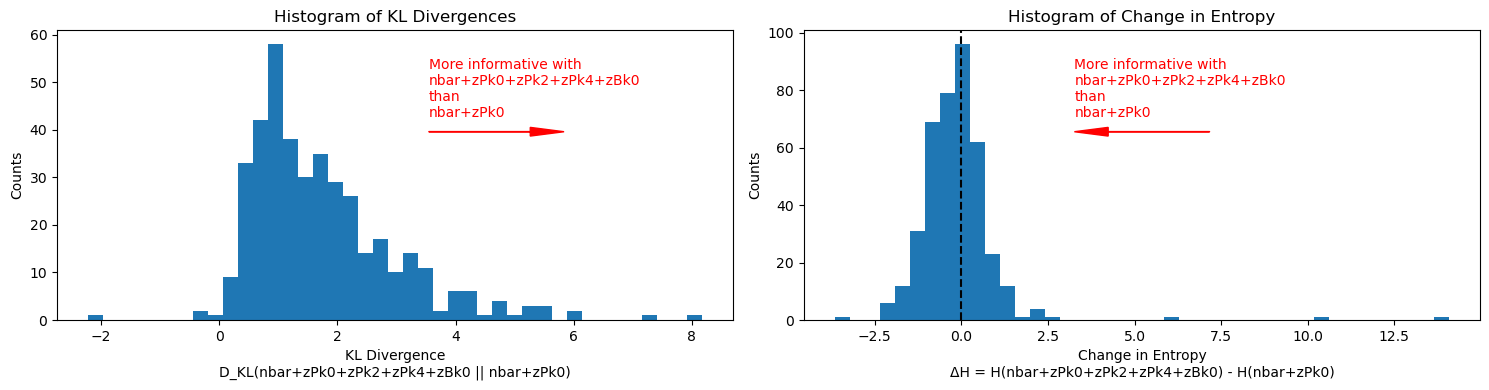

In [ ]:
bins = 41

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# D_KL
axs[0].hist(all_D_KL, bins=bins)
axs[0].set_xlabel(f'KL Divergence\nD_KL({s1} || {s0})')
axs[0].set_ylabel('Counts')
axs[0].set_title('Histogram of KL Divergences')
axs[0].text(0.55, 0.7, f'More informative with\n{s1}\nthan\n{s0}', transform=axs[0].transAxes, color='r')
axs[0].arrow(0.55, 0.65, 0.15, 0.0, transform=axs[0].transAxes, 
          head_width=0.03, head_length=0.05, fc='r', ec='r')

# Delta H
axs[1].hist(all_delta_H, bins=bins)
axs[1].set_xlabel(f'Change in Entropy\nΔH = H({s1}) - H({s0})')
axs[1].set_ylabel('Counts')
axs[1].set_title('Histogram of Change in Entropy')
axs[1].text(0.4, 0.7, f'More informative with\n{s1}\nthan\n{s0}', transform=axs[1].transAxes, color='r')
axs[1].arrow(0.6, 0.65, -0.15, 0.0, transform=axs[1].transAxes, 
          head_width=0.03, head_length=0.05, fc='r', ec='r')
axs[1].axvline(0, color='k', linestyle='--')
m = all_delta_H < 0
print(f"Number of test points more informative with {s1} than {s0}: {np.sum(m)} out of {len(all_delta_H)}")

fig.tight_layout()
fig.savefig('kl_divergence_and_delta_H.png', bbox_inches='tight')

# Plot example data vector

Getting summaries from: /anvil/scratch/x-dbartlett/cmass/quijote/nbody_nonoise_appended/models/galaxy
Processing summary: nbar+zPk0
Processing summary: nbar+zPk0+zPk2+zPk4
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0
Processing summary: nbar+zPk0+zPk2+zPk4+zBk0+zBk2
Processing summary: nbar+zPk0+zPk2+zPk4+zQk0


/tmp/ipykernel_2897107/1019103273.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


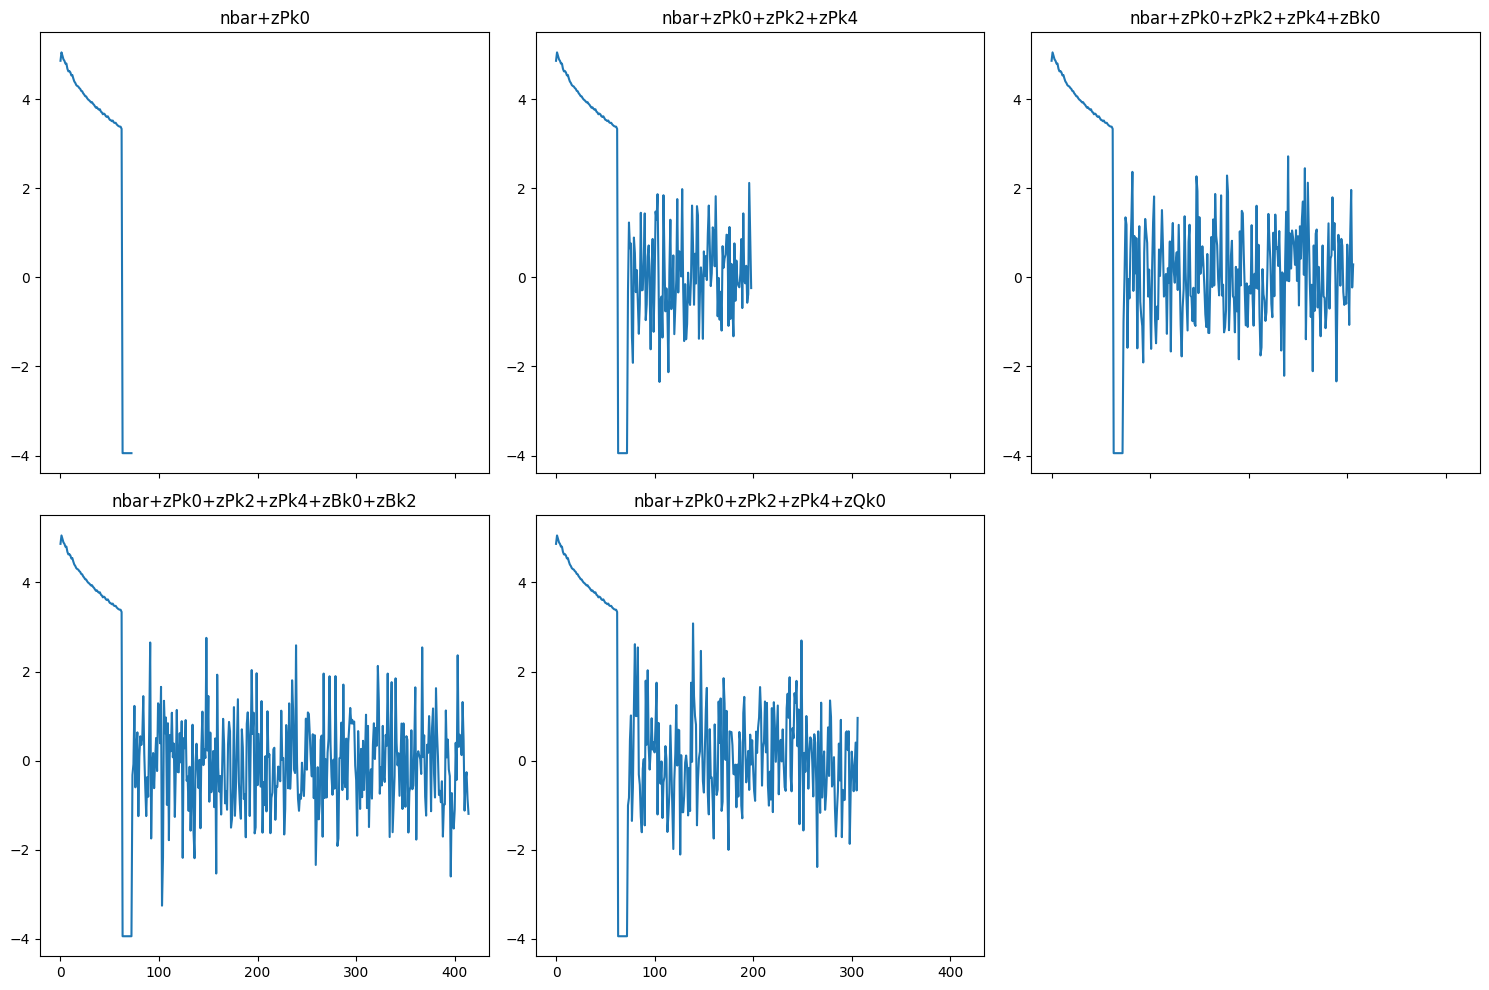

In [25]:
post_dir = get_post_dir()
all_summaries = get_all_summaries()

ncol = 3
nrow = (len(all_summaries) + ncol - 1) // ncol

fig, axs = plt.subplots(nrow, ncol, figsize=(5 * ncol, 5 * nrow), constrained_layout=True, sharex=True)
axs = axs.flatten()

for i, summary in enumerate(all_summaries):
    print(f"Processing summary: {summary}")
    xval = np.load(pjoin(post_dir, summary, 'kmin-0.0_kmax-0.4', 'x_val.npy'))

    _, trues_0 = get_samples(summary)
    unique_vals = np.unique(trues_0[par])
    median = np.median(unique_vals)
    idx = np.argmin(np.abs(unique_vals - median))

    x = xval[idx,:]

    axs[i].plot(x)
    axs[i].set_title(summary)


plt.tight_layout()

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

fig.savefig('example_data_vector.png', bbox_inches='tight')